In [1]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import numpy as np

In [ ]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import numpy as np

# Define data transformations
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset
train_dataset = datasets.ImageFolder(root='data/train', transform=transform_train)
val_dataset = datasets.ImageFolder(root='data/validation', transform=transform_val)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Replace the final layer for 6-class classification
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 6)

# Move the model to the appropriate device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)


In [ ]:
# Calculate class weights based on the dataset
class_counts = np.bincount([label for _, label in train_dataset.samples])
class_weights = 1.0 / class_counts
weights = torch.FloatTensor(class_weights).to(device)

# Define the loss function
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        correct = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

        train_accuracy = correct / len(train_loader.dataset)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0
        correct = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()

        val_accuracy = correct / len(val_loader.dataset)
        val_loss /= len(val_loader.dataset)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

# Train the model
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10)

# Save the trained model
torch.save(model.state_dict(), 'stamp_case_classifier.pth')


In [ ]:
from PIL import Image

def classify_image(image_path, model):
    """
    Classify an image into one of six cases.
    """
    model.eval()
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        _, predicted_class = torch.max(outputs, 1)
    
    # Map the predicted class index to a human-readable label
    class_labels = {
        0: "Case 1: Single correct stamp",
        1: "Case 2: Single incorrect stamp",
        2: "Case 3: Overlapping correct stamps",
        3: "Case 4: Overlapping with at least one incorrect",
        4: "Case 5: Non-overlapping correct stamps",
        5: "Case 6: Non-overlapping with at least one incorrect"
    }
    return class_labels[predicted_class.item()]


In [ ]:
import os
import time

def monitor_and_classify(folder_path, model, check_interval=1):
    """
    Monitor a folder for new images and classify them into one of six cases.
    """
    processed_files = set()

    while True:
        for file_name in os.listdir(folder_path):
            if file_name.endswith(('.jpg', '.png')) and file_name not in processed_files:
                image_path = os.path.join(folder_path, file_name)
                predicted_class = classify_image(image_path, model)
                print(f"Image: {file_name}, Predicted Case: {predicted_class}")
                processed_files.add(file_name)

        time.sleep(check_interval)

# Example usage
folder_path = "path/to/saved/images"
monitor_and_classify(folder_path, model)


In [3]:
##### test
!pip install seaborn scikit-learn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ------------- -------------------------- 3.7/11.1 MB 19.8 MB/s eta 0:00:01
   ---------------------------------------  11.0/11.1 MB 29.9 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 26.7 MB/s eta 0:00:00


In [2]:



# Set up CUDA in OS
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
# Import libabries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import seaborn as sn
import pandas as pd
import torchvision
from torchvision import *
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image
import torchvision.transforms as T
from torchvision import datasets, models, transforms
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import time
import copy

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Check version of Pytorch
print(torch. __version__)

2.5.1+cpu


In [4]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [5]:
# Find out if a GPU is available
use_cuda = torch.cuda.is_available()
use_cuda

False

In [6]:
# Set up path for data after downloading
default_dir = r"C:\Users\User\CD_DL_241210\CD_DL_241210\ws\Skin cancer dataset"
train_dir = default_dir + "/train/"
test_dir = default_dir + "/test/"
train_classa_dir = default_dir + "/train/benign/"
train_classb_dir = default_dir + "/train/malignant/"
test_classa_dir = default_dir + "/test/benign/"
test_classb_dir = default_dir + "/test/malignant/"

This is benign skin cancer


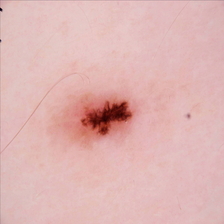

In [7]:
# Display image for reference
white_torch = torchvision.io.read_image(default_dir + '/test/benign/1.jpg')
print("This is benign skin cancer")
T.ToPILImage()(white_torch)

This is malignant skin cancer


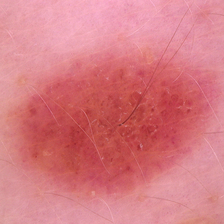

In [8]:
# Display image for reference
wh = torchvision.io.read_image(default_dir + '/test/benign/44.jpg')
print("This is malignant skin cancer")
T.ToPILImage()(wh)

In [9]:
# Create transform function
transforms_train = transforms.Compose([
    transforms.Resize((224, 224)),   #must same as here
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(), # data augmentation
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # normalization
])
transforms_test = transforms.Compose([
    transforms.Resize((224, 224)),   #must same as here
     transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [32]:
# ... existing transforms and ImageFolder creation ...

# Create the full datasets first
train_dataset_raw = datasets.ImageFolder(train_dir, transforms_train)
test_dataset_raw = datasets.ImageFolder(test_dir, transforms_test)

# # Take subsets of the data to get desired sizes
# train_dataset = torch.utils.data.Subset(train_dataset_raw, range(320))
# test_dataset = torch.utils.data.Subset(test_dataset_raw, range(120))

# # Create data loaders
# train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=12, shuffle=True, num_workers=0)
# test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=12, shuffle=False, num_workers=0)




# ... existing imports ...
import random

# Set random seed for reproducibility
random.seed(42)

# Get total dataset sizes
total_train_size = len(train_dataset_raw)
total_test_size = len(test_dataset_raw)

# Randomly sample indices
train_indices = random.sample(range(total_train_size), 320)
test_indices = random.sample(range(total_test_size), 120)

# Create subsets using random indices
train_dataset = torch.utils.data.Subset(train_dataset_raw, train_indices)
test_dataset = torch.utils.data.Subset(test_dataset_raw, test_indices)

# Create data loaders (unchanged)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=12, shuffle=True, num_workers=0)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=12, shuffle=False, num_workers=0)

In [33]:
# print('Train dataset size:', len(train_dataset))
# print('Test dataset size:', len(test_dataset))
# class_names = train_dataset.classes
# print('Class names:', class_names)


# ... existing code ...
print('Train dataset size:', len(train_dataset))
print('Test dataset size:', len(test_dataset))

# Access classes from the original ImageFolder dataset
class_names = train_dataset_raw.classes
print('Class names:', class_names)

Train dataset size: 320
Test dataset size: 120
Class names: ['benign', 'malignant']


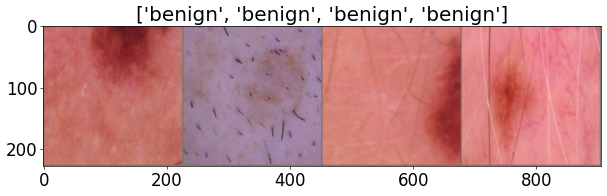

In [22]:
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 60
plt.rcParams.update({'font.size': 20})
def imshow(input, title):
    # torch.Tensor => numpy
    input = input.numpy().transpose((1, 2, 0))
    # undo image normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    input = std * input + mean
    input = np.clip(input, 0, 1)
    # display images
    plt.imshow(input)
    plt.title(title)
    plt.show()
# load a batch of train image
iterator = iter(train_dataloader)
# visualize a batch of train image
inputs, classes = next(iterator)
out = torchvision.utils.make_grid(inputs[:4])
imshow(out, title=[class_names[x] for x in classes[:4]])

In [34]:
model = models.resnet50(pretrained=True)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [35]:
num_features = model.fc.in_features 
print('Number of features from pre-trained model', num_features)

Number of features from pre-trained model 2048


In [36]:
# Add a fully-connected layer for classification
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

In [44]:
# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
# optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [45]:
# Set the random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

In [46]:
#### Train model
train_loss=[]
train_accuary=[]
test_loss=[]
test_accuary=[]

num_epochs = 10   #(set no of epochs)
start_time = time.time() #(for showing time)

In [48]:

# Start loop
for epoch in range(num_epochs): #(loop for every epoch)
    print("Epoch {}/{} running".format(epoch+1, num_epochs)) #(printing message)
    """ Training Phase """
    model.train()    #(training model)
    running_loss = 0.   #(set loss 0)
    running_corrects = 0 
    # load a batch data of images
    for i, (inputs, labels) in enumerate(train_dataloader):
        inputs = inputs.to(device)
        labels = labels.to(device) 
        # forward inputs and get output
        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        # get loss value and update the network weights
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data).item()
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects / len(train_dataset) * 100.
    # Append result
    train_loss.append(epoch_loss)
    train_accuary.append(epoch_acc)
    # Print progress
    print('[Train #{}] Loss: {:.4f} Acc: {:.4f}% Time: {:.4f}s'.format(epoch+1, epoch_loss, epoch_acc, time.time() -start_time))
    """ Testing Phase """
    model.eval()
    with torch.no_grad():
        running_loss = 0.
        running_corrects = 0
        for inputs, labels in test_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            running_corrects += torch.sum(preds == labels.data).item()
        epoch_loss = running_loss / len(test_dataset)
        epoch_acc = running_corrects / len(test_dataset) * 100.
        # Append result
        test_loss.append(epoch_loss)
        test_accuary.append(epoch_acc)
        # Print progress
        print('[Test #{}] Loss: {:.4f} Acc: {:.4f}% Time: {:.4f}s'.format(epoch+1, epoch_loss, epoch_acc, time.time()- start_time))
        
        
        # epoch 30, resnet18 : 14m, optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)
        #epoch 10, resnet50: 13m, optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)
#        [Train #10] Loss: 0.0332 Acc: 83.4375% Time: 784.9627s
# [Test #10] Loss: 0.0395 Acc: 73.3333% Time: 794.9909s

#epoch 10, resnet50: , 14m, adam, 
# [Train #10] Loss: 0.0175 Acc: 93.1250% Time: 881.8872s
# [Test #10] Loss: 0.0645 Acc: 75.8333% Time: 890.8008s

Epoch 1/10 running
[Train #1] Loss: 0.0165 Acc: 90.9375% Time: 1123.3828s
[Test #1] Loss: 0.0459 Acc: 75.8333% Time: 1131.6227s
Epoch 2/10 running
[Train #2] Loss: 0.0159 Acc: 90.3125% Time: 1200.6138s
[Test #2] Loss: 0.0622 Acc: 79.1667% Time: 1208.7045s
Epoch 3/10 running
[Train #3] Loss: 0.0153 Acc: 94.3750% Time: 1279.9575s
[Test #3] Loss: 0.0808 Acc: 75.0000% Time: 1288.6593s
Epoch 4/10 running
[Train #4] Loss: 0.0094 Acc: 95.0000% Time: 1369.4832s
[Test #4] Loss: 0.0615 Acc: 80.0000% Time: 1379.2432s
Epoch 5/10 running
[Train #5] Loss: 0.0120 Acc: 95.9375% Time: 1463.0077s
[Test #5] Loss: 0.0654 Acc: 79.1667% Time: 1472.8956s
Epoch 6/10 running
[Train #6] Loss: 0.0126 Acc: 93.7500% Time: 1557.5259s
[Test #6] Loss: 0.0549 Acc: 80.0000% Time: 1567.6756s
Epoch 7/10 running
[Train #7] Loss: 0.0131 Acc: 94.3750% Time: 1645.8888s
[Test #7] Loss: 0.1286 Acc: 69.1667% Time: 1655.2794s
Epoch 8/10 running
[Train #8] Loss: 0.0185 Acc: 91.2500% Time: 1737.2580s
[Test #8] Loss: 0.0863 Acc: 79

In [49]:
save_path = 'custom-classifier_resnet_18_final.pth'
torch.save(model.state_dict(), save_path)

ValueError: x and y must have same first dimension, but have shapes (10,) and (20,)

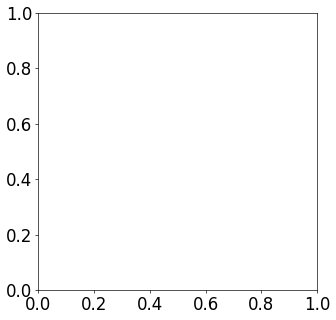

In [50]:
# Plot
plt.figure(figsize=(6,6))
plt.plot(np.arange(1,num_epochs+1), train_accuary,'-o')
plt.plot(np.arange(1,num_epochs+1), test_accuary,'-o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Test'])
plt.title('Train vs Test Accuracy over time')
plt.show()

In [51]:
# Get data to check on the performance of each label
y_pred = []
y_true = []

num_epochs = 30   #(set no of epochs)
start_time = time.time() #(for showing time)
# Start loop
for epoch in range(num_epochs): #(loop for every epoch)
    model.eval()
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs) # Feed Network
            outputs = (torch.max(torch.exp(outputs), 1)[1]).data.cpu().numpy()
            y_pred.extend(outputs) # Save Prediction
            labels = labels.data.cpu().numpy()
            y_true.extend(labels) # Save Truth

In [53]:
# Visualization and result
# constant for classes
# classes = test_dataset.classes
# Build confusion matrix
print("Accuracy on Training set: ",accuracy_score(y_true, y_pred))
print('Confusion matrix: \n', confusion_matrix(y_true, y_pred))
print('Classification report: \n', classification_report(y_true, y_pred))
# Plot
cf_matrix = confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(cf_matrix, index = [i for i in classes], columns = [i for i in classes])
plt.figure(figsize = (7,7))
plt.title("Confusion matrix for Skin Cancer classification ")
sn.heatmap(df_cm, annot=True)

Accuracy on Training set:  0.7166666666666667
Confusion matrix: 
 [[1350  570]
 [ 450 1230]]
Classification report: 
               precision    recall  f1-score   support

           0       0.75      0.70      0.73      1920
           1       0.68      0.73      0.71      1680

    accuracy                           0.72      3600
   macro avg       0.72      0.72      0.72      3600
weighted avg       0.72      0.72      0.72      3600



ValueError: Shape of passed values is (2, 2), indices imply (12, 12)

In [ ]:
#####################################################################

Accuracy on test set: 43.79%

Classification Report:
              precision    recall  f1-score   support

      benign       0.00      0.00      0.00       360
   malignant       0.45      0.96      0.61       300

    accuracy                           0.44       660
   macro avg       0.22      0.48      0.30       660
weighted avg       0.20      0.44      0.28       660



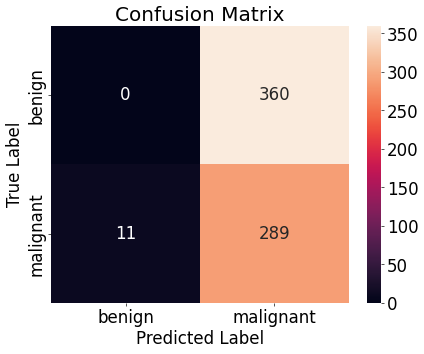

In [31]:
### test for just pre trained model

# Load pre-trained ResNet18 and modify for inference
model = models.resnet18(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)  # Modify for binary classification (2 classes)
model = model.to(device)
model.eval()  # Set to evaluation mode

# Perform inference on test dataset
def evaluate_model(model, test_dataloader):
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():  # No gradient computation needed
        for inputs, labels in test_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = 100 * correct / total
    print(f'Accuracy on test set: {accuracy:.2f}%')
    
    # Print detailed classification report
    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # Create confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sn.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


# load dataset
test_dataset_raw = datasets.ImageFolder(test_dir, transforms_test)

# Create data loaders
test_dataloader = torch.utils.data.DataLoader(test_dataset_raw, batch_size=12, shuffle=False, num_workers=0)

# Run evaluation
evaluate_model(model, test_dataloader)